In [86]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
import cv2

In [87]:
# Import Labels' Dictionary, Train, Test

import pickle

with open("allDataset.pkl", "rb") as f:
  allDataset = pickle.load(f)

with open("orderLabels.pkl", "rb") as f:
  orderLabels = pickle.load(f)

In [88]:
# Get x_train, y_train

# print(cnn_pre_onehot)
# print(allDataset)

x = allDataset.iloc[:, 2:]
x.drop(columns = ["img_id", "diagnostic"], inplace = True)
# x = pd.concat([x.reset_index(drop = True), cnn_pre_onehot], axis = 1)
print(x.keys())
print(len(x.keys()))


y = allDataset["diagnostic"]

Index(['age', 'gender', 'smoke', 'drink', 'skin_cancer_history',
       'cancer_history', 'pesticide', 'biopsed', 'grew', 'hurt', 'bleed',
       'itch', 'elevation', 'changed', 'diameter_1', 'diameter_2',
       'has_sewage_system', 'has_piped_water', 'race', 'region_ARM',
       'region_BACK', 'region_CHEST', 'region_EAR', 'region_FACE',
       'region_FOOT', 'region_FOREARM', 'region_HAND', 'region_LIP',
       'region_NECK', 'region_NOSE', 'region_SCALP', 'region_THIGH'],
      dtype='object')
32


In [89]:
# Split The Data

from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.3, random_state = 42)

In [90]:
print(x_train.shape)
print(y_train.shape)

(4825, 32)
(4825,)


In [91]:
# Labels OneHotEncoding

from sklearn.preprocessing import LabelEncoder

labelEncoder = LabelEncoder()
y_train = labelEncoder.fit_transform(y_train)
y_test = labelEncoder.transform(y_test)
print(labelEncoder.classes_)

orderLabels = labelEncoder.classes_

print(labelEncoder.classes_[0])

['ACK' 'BCC' 'MEL' 'NEV' 'SCC' 'SEK']
ACK


In [92]:
import tensorflow as tf
from tensorflow.keras import models, layers
from tensorflow.keras.models import Sequential
from keras.layers import Dense, Dropout

print(y_train)
y_train = tf.keras.utils.to_categorical(y_train)
y_test = tf.keras.utils.to_categorical(y_test)
print(y_train)

ann = Sequential()

[0 1 3 ... 5 5 0]
[[1. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0.]
 ...
 [0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 1.]
 [1. 0. 0. 0. 0. 0.]]


In [93]:
print(x_train)
print(y_train)

           age  gender  smoke  drink  skin_cancer_history  cancer_history  \
5711  1.606859     0.6    0.4    0.2                  0.2             0.2   
5550  1.103442     0.0    0.0    0.0                  1.0             1.0   
6436 -1.602423     0.4    0.0    0.4                  0.4             0.6   
4920 -1.854131     0.8    0.0    0.8                  0.2             0.4   
4101 -0.469735     0.0    0.0    0.0                  1.0             0.0   
...        ...     ...    ...    ...                  ...             ...   
3772 -0.469735     0.0    0.0    0.0                  1.0             0.0   
5191  1.858567     1.0    0.0    0.0                  0.0             1.0   
5226  0.222463     0.0    0.0    0.0                  1.0             0.0   
5390  0.474171     0.6    0.4    0.4                  0.2             0.4   
860   0.914661     0.4    0.0    0.0                  0.0             0.4   

      pesticide  biopsed  grew  hurt  ...  region_EAR  region_FACE  \
5711 

In [94]:
ann.add(Dense(units = 128, input_shape = (x_train.shape[1], ), activation = "relu"))
ann.add(Dense(units = 64, activation = "relu"))
ann.add(Dropout(0.3))
ann.add(Dense(units = 32, activation = "relu"))
ann.add(Dropout(0.3))
ann.add(Dense(units = 6, activation = "softmax"))

d:\2. My Learning\03. Data Science\02. Learn\02. NTI-Huawei\16. Final Project\Project\tf_env\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [95]:
ann.compile(optimizer = "adam", loss = "categorical_crossentropy", metrics = ["accuracy"])
hist = ann.fit(x_train, y_train, epochs = 100, validation_split = 0.2, batch_size = 128)

Epoch 1/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.3806 - loss: 1.5356 - val_accuracy: 0.6187 - val_loss: 1.2047
Epoch 2/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6036 - loss: 1.1682 - val_accuracy: 0.7098 - val_loss: 0.8883
Epoch 3/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6837 - loss: 0.9362 - val_accuracy: 0.7378 - val_loss: 0.7532
Epoch 4/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7142 - loss: 0.8499 - val_accuracy: 0.7793 - val_loss: 0.6866
Epoch 5/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7365 - loss: 0.7743 - val_accuracy: 0.7824 - val_loss: 0.6514
Epoch 6/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7492 - loss: 0.7329 - val_accuracy: 0.7834 - val_loss: 0.6338
Epoch 7/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7596 - loss: 0.7030 - val_accuracy: 0.7907 - val_loss: 0.6068
Epoch 8/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7622 - loss: 0.6783 - val_accuracy: 0.7865 - 

In [96]:
ann.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_24 (Dense)                │ (None, 128)            │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 6)              │           198 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,276 (172.96 KB)

 Trainable params: 14,758 (57.65 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 29,518 (115.31 KB)

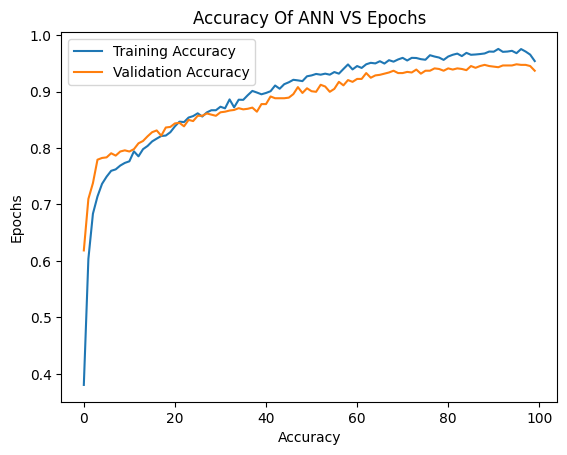

In [97]:
# Accuracy Visualization

plt.plot(hist.history["accuracy"], label = "Training Accuracy")
plt.plot(hist.history["val_accuracy"], label = "Validation Accuracy")

plt.title("Accuracy Of ANN VS Epochs")
plt.xlabel("Accuracy")
plt.ylabel("Epochs")

plt.legend()
plt.show()

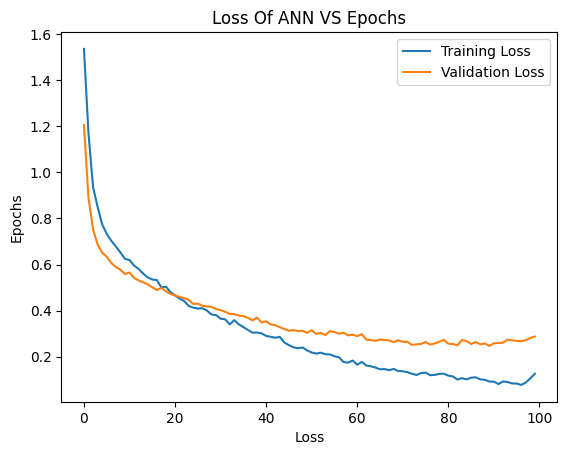

In [98]:
# Loss Visualization

plt.plot(hist.history["loss"], label = "Training Loss")
plt.plot(hist.history["val_loss"], label = "Validation Loss")

plt.title("Loss Of ANN VS Epochs")
plt.xlabel("Loss")
plt.ylabel("Epochs")

plt.legend()
plt.show()

In [99]:
# Evaluate The model

model_loss, model_accuracy = ann.evaluate(x_test, y_test)

print(f"Model Loss {model_loss}")
print(f"Model Accuracy {model_accuracy}")

65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9415 - loss: 0.2505
Model Loss 0.2504861354827881
Model Accuracy 0.9415176510810852


In [100]:
# Predict ANN Input

input = x_train.iloc[0].values
input = np.expand_dims(input, axis = 0)

print(ann.predict(input))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
[[8.7579656e-01 8.6250387e-02 3.7435598e-06 2.9836899e-06 1.7508414e-03
  3.6195453e-02]]


In [101]:
# Save Model

ann.save("ann_model.keras")

In [102]:
# Export Train, Test

import pickle

with open("x_train_ann.pkl", "wb") as f:
  pickle.dump(x_train, f)

with open("y_train_ann.pkl", "wb") as f:
  pickle.dump(y_train, f)

with open("x_test_ann.pkl", "wb") as f:
  pickle.dump(x_test, f)

with open("y_test_ann.pkl", "wb") as f:
  pickle.dump(y_test, f)